In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "train.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "adilshamim8/predict-calorie-expenditure",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_161/2007941106.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 33.8M/33.8M [00:00<00:00, 45.5MB/s]


First 5 records:    id     Sex  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  Calories
0   0    male   36   189.0    82.0      26.0       101.0       41.0     150.0
1   1  female   64   163.0    60.0       8.0        85.0       39.7      34.0
2   2  female   51   161.0    64.0       7.0        84.0       39.8      29.0
3   3    male   20   192.0    90.0      25.0       105.0       40.7     140.0
4   4  female   38   166.0    61.0      25.0       102.0       40.6     146.0


In [ ]:
# Basic system and data handling
import os
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities (for data preparation)
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Plot settings
plt.style.use('seaborn-v0_8')
sns.set_context("notebook")

In [ ]:
os.getcwd()

# Load dataset
# df = pd.read_csv("Energy_consumption_dataset.csv") # This line is redundant as df is already loaded

# Preview first few rows
df.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


MIssing values and Duplicates

In [ ]:
# Missing values count
missing_values = df.isnull().sum()

# Missing values percentage
missing_percent = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": missing_percent
})

missing_df

,Missing_Count,Missing_Percentage
id,0,0.0
Sex,0,0.0
Age,0,0.0
Height,0,0.0
Weight,0,0.0
Duration,0,0.0
Heart_Rate,0,0.0
Body_Temp,0,0.0
Calories,0,0.0


In [ ]:
# Count duplicates
duplicate_count =df.duplicated().sum()
print("Total duplicate rows:", duplicate_count)



Total duplicate rows: 0


Outliers

In [ ]:
outlier_info = {}

num_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude 'id' column as it's an identifier and not a feature for outlier detection
if 'id' in num_cols:
    num_cols.remove('id')

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_info[col] = outlier_count

pd.DataFrame.from_dict(outlier_info, orient='index', columns=['Outlier_Count'])

,Outlier_Count
Age,0
Height,14
Weight,9
Duration,0
Heart_Rate,36
Body_Temp,14919
Calories,139


Feature Engineering

Get subset

In [ ]:
df_subset = df.sample(n=100000, random_state=42)

split dataset

In [ ]:
train_data, test_data = train_test_split(
    df_subset,
    test_size=0.30,     # 30% test data
    random_state=42,
    shuffle=True
)


In [ ]:
print("Total subset size:", df_subset.shape)
print("Train size:", train_data.shape)
print("Test size:", test_data.shape)



Total subset size: (100000, 9)
Train size: (70000, 9)
Test size: (30000, 9)


In [ ]:
df['BMI'] = df['BMI'].clip(lower=10, upper=60)
df['Max_Heart_Rate'] = df['Max_Heart_Rate'].clip(lower=60, upper=220)



FAMD

In [ ]:
!pip install prince
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from prince import FAMD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.5/179.5 kB 10.9 MB/s eta 0:00:00


In [ ]:
def prepare_data_for_famd(data):
    """Prepare data for FAMD analysis"""
    # Separate features (drop id and target 'Calories')
    features = data.drop(['id', 'Calories'], axis=1)

    # Separate numerical and categorical columns
    categorical_cols = ['Sex']
    numerical_cols = ['Age', 'Height', 'Weight', 'Duration',
                     'Heart_Rate', 'Body_Temp']

    # Encode categorical variable
    le = LabelEncoder()
    features_encoded = features.copy()
    features_encoded['Sex'] = le.fit_transform(features_encoded['Sex'])

    return features_encoded, numerical_cols, categorical_cols

In [ ]:
# This cell is now empty as its content has been moved to cell ZpcBav9vg57c.

In [ ]:
features_encoded, numerical_cols, categorical_cols = prepare_data_for_famd(train_data)

print("First 5 records of features_encoded:")
print(features_encoded.head())
print("\nNumerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

First 5 records of features_encoded:
        Sex  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
410603    1   21   184.0    84.0      21.0        96.0       40.3
235221    0   27   158.0    54.0      17.0        98.0       40.3
49013     1   36   181.0    78.0      13.0        92.0       40.2
336904    0   31   172.0    72.0      12.0        82.0       40.0
508043    1   38   178.0    75.0       6.0        90.0       39.1

Numerical columns: ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']
Categorical columns: ['Sex']


In [ ]:
train_features, numerical_cols, categorical_cols = prepare_data_for_famd(train_data)

In [ ]:
# 5. Perform FAMD
print("\n" + "="*50)
print("Performing FAMD Analysis...")
print("="*50)


Performing FAMD Analysis...


In [ ]:
# Initialize and fit FAMD
famd = FAMD(
    n_components=min(10, len(numerical_cols) + len(categorical_cols)),
    n_iter=10,
    random_state=42
)

famd.fit(features_encoded)

FAMD(n_components=7, n_iter=10, random_state=42)

In [ ]:
# Get the transformed data
train_famd_scores = famd.transform(features_encoded)

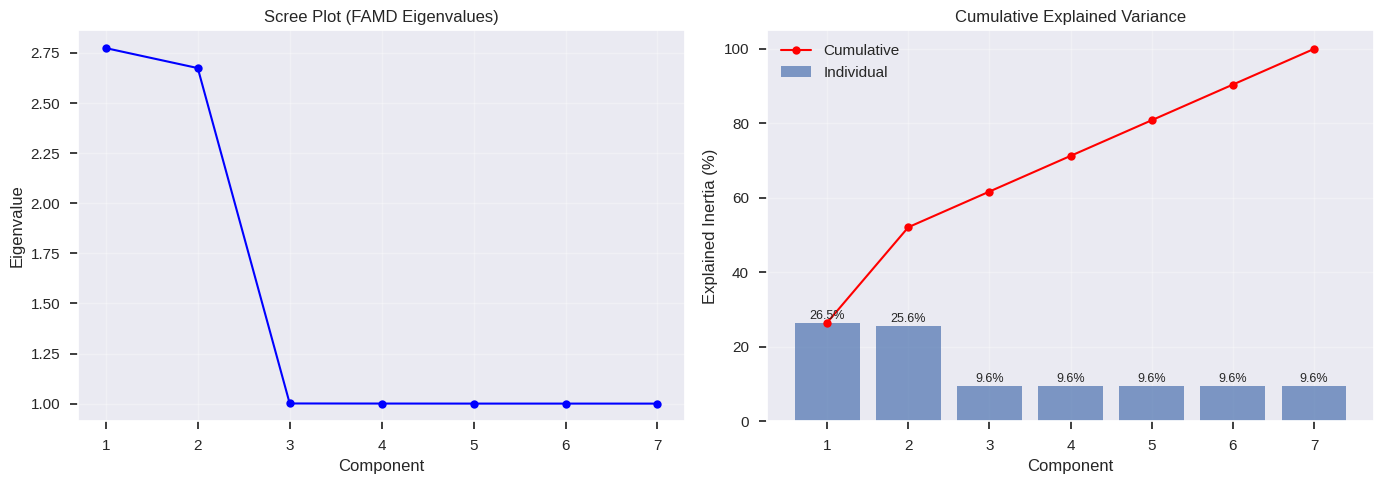


Variance Explained by Components:
----------------------------------------
Component 1: 26.55% (Cumulative: 26.55%)
Component 2: 25.59% (Cumulative: 52.14%)
Component 3: 9.58% (Cumulative: 61.72%)
Component 4: 9.57% (Cumulative: 71.29%)
Component 5: 9.57% (Cumulative: 80.86%)
Component 6: 9.57% (Cumulative: 90.43%)
Component 7: 9.57% (Cumulative: 100.00%)


In [ ]:
# 6. Create scree plot and cumulative variance plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (eigenvalues)
eigenvalues = famd.eigenvalues_
axes[0].plot(range(1, len(eigenvalues) + 1), eigenvalues, 'bo-')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Scree Plot (FAMD Eigenvalues)')
axes[0].grid(True, alpha=0.3)

# Add horizontal line at eigenvalue=1 (Kaiser criterion)
#axes[0].axhline(y=1, color='r', linestyle='--', alpha=0.7, label='Kaiser criterion (λ=1)')
#axes[0].legend()

# Calculate explained inertia from eigenvalues
explained_inertia = eigenvalues / np.sum(eigenvalues) * 100 # Convert to percentage

# Cumulative variance plot
cumulative_variance = np.cumsum(explained_inertia)
axes[1].bar(range(1, len(cumulative_variance) + 1), explained_inertia,
            alpha=0.7, label='Individual')
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
             'ro-', label='Cumulative')
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Explained Inertia (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Add percentage labels on bars
for i, v in enumerate(explained_inertia):
    axes[1].text(i + 1, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('famd_analysis_plots.png', dpi=300, bbox_inches='tight')
plt.show()
# Print variance explained
print("\nVariance Explained by Components:")
print("-" * 40)
for i, (var, cum_var) in enumerate(zip(explained_inertia, cumulative_variance)):
    print(f"Component {i+1}: {var:.2f}% (Cumulative: {cum_var:.2f}%)")

In [ ]:
# 7. Determine optimal number of components
optimal_components = np.argmax(cumulative_variance >= 80) + 1
print(f"\n→ Components needed for 80% variance: {optimal_components}")



→ Components needed for 80% variance: 5


In [ ]:
# 8. Re-run FAMD with optimal components
print(f"\nRe-running FAMD with {optimal_components} components...")
famd_optimal = FAMD(
    n_components=optimal_components,
    n_iter=10,
    random_state=42
)
famd_optimal.fit(features_encoded)
train_famd_optimal = famd_optimal.transform(features_encoded)


Re-running FAMD with 5 components...


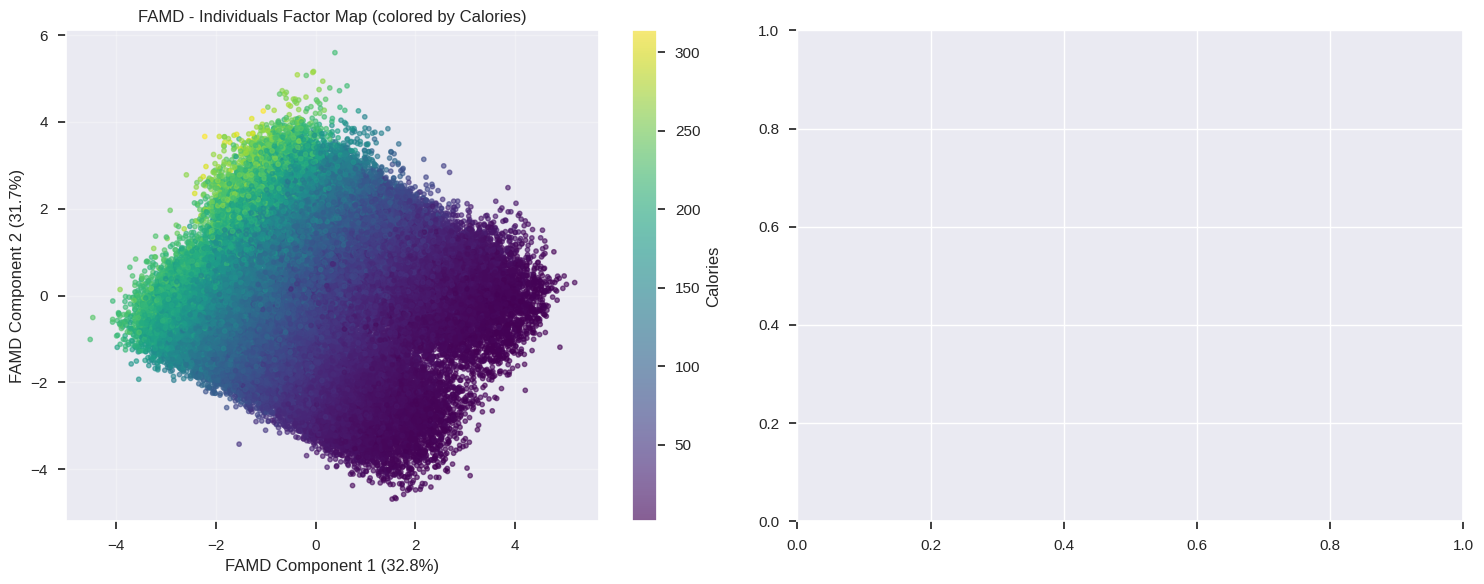

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(15, 6))

# Calculate explained inertia for optimal components
explained_inertia_optimal = famd_optimal.eigenvalues_ / np.sum(famd_optimal.eigenvalues_) * 100

# Plot 1: Individuals factor map (first two components)
scatter = axes[0].scatter(train_famd_optimal.iloc[:, 0],
                         train_famd_optimal.iloc[:, 1],
                         c=train_data['Calories'], cmap='viridis',
                         alpha=0.6, s=10)
axes[0].set_xlabel(f'FAMD Component 1 ({explained_inertia_optimal[0]:.1f}%)')
axes[0].set_ylabel(f'FAMD Component 2 ({explained_inertia_optimal[1]:.1f}%)')
axes[0].set_title('FAMD - Individuals Factor Map (colored by Calories)')
plt.colorbar(scatter, ax=axes[0], label='Calories')
axes[0].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 10. Clustering on FAMD components
print("\n" + "="*50)
print("Clustering Analysis on FAMD Components")
print("="*50)



Clustering Analysis on FAMD Components


In [ ]:
# Find optimal number of clusters using silhouette score
silhouette_scores = []
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(train_famd_optimal)
    silhouette_scores.append(silhouette_score(train_famd_optimal, labels))
    inertias.append(kmeans.inertia_)

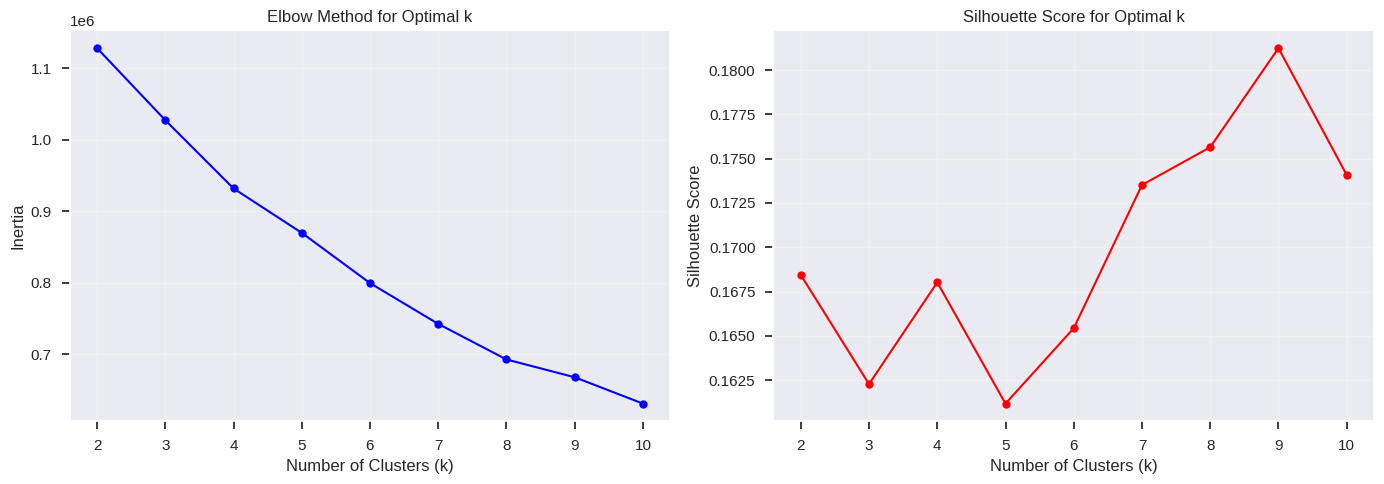


Optimal number of clusters: 9 (Silhouette score: 0.181)


In [ ]:
# Plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Optimal k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('clustering_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters: {optimal_k} (Silhouette score: {max(silhouette_scores):.3f})")


In [ ]:
# Perform final clustering
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(train_famd_optimal)

In [ ]:
# Add cluster labels to original train data
train_data_with_clusters = train_data.copy()
train_data_with_clusters['Cluster'] = cluster_labels

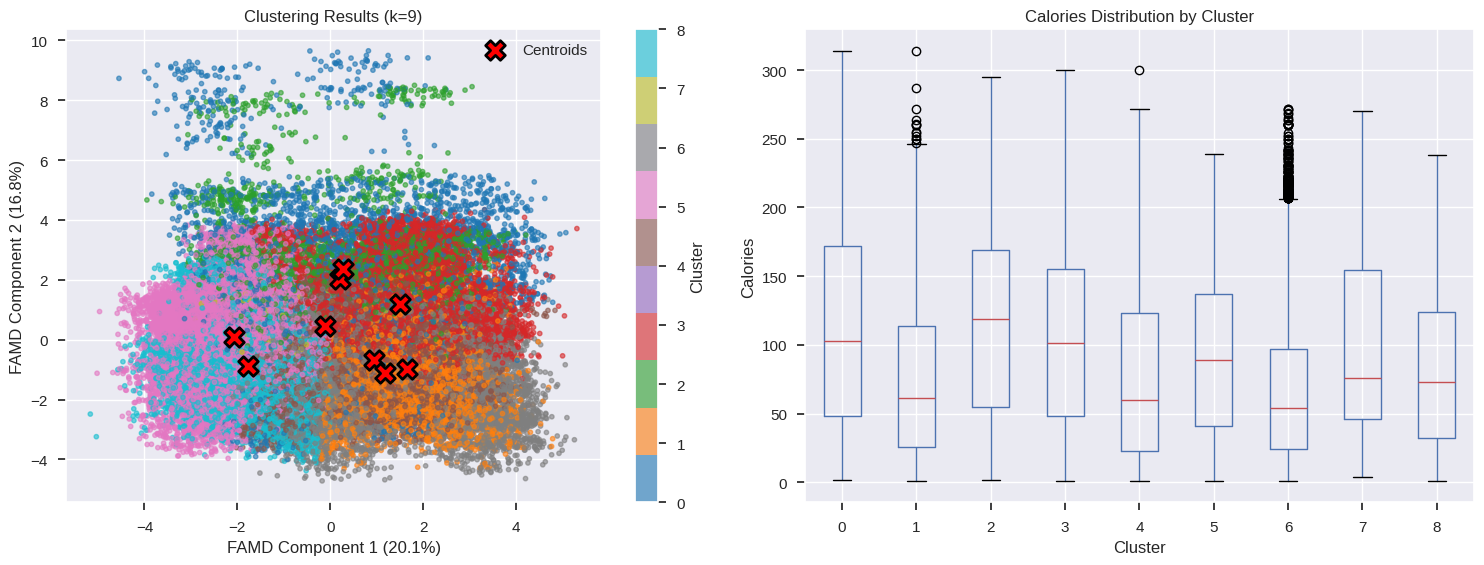

In [ ]:
# Visualize clusters
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Cluster plot on FAMD components
scatter1 = axes[0].scatter(train_famd_optimal.iloc[:, 0],
                          train_famd_optimal.iloc[:, 1],
                          c=cluster_labels, cmap='tab10', alpha=0.6, s=10)
axes[0].set_xlabel(f'FAMD Component 1 ({explained_inertia_optimal[0]:.1f}%)')
axes[0].set_ylabel(f'FAMD Component 2 ({explained_inertia_optimal[1]:.1f}%)')
axes[0].set_title(f'Clustering Results (k={optimal_k})')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Cluster centers
centers = kmeans_final.cluster_centers_
axes[0].scatter(centers[:, 0], centers[:, 1],
               c='red', marker='X', s=200, edgecolors='black',
               linewidths=2, label='Centroids')
axes[0].legend()
# Box plot of Calories by cluster
train_data_with_clusters.boxplot(column='Calories', by='Cluster', ax=axes[1])
axes[1].set_title('Calories Distribution by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Calories')
plt.suptitle('')

plt.tight_layout()
plt.savefig('clustering_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 11. Cluster profiling
print("\n" + "="*50)
print("Cluster Profiles")
print("="*50)

cluster_profile = train_data_with_clusters.groupby('Cluster').agg({
    'Age': 'mean',
    'BMI': 'mean',
    'Duration': 'mean',
    'Heart_Rate': 'mean',
    'Body_Temp': 'mean',
    'Calories': ['mean', 'count'],
    'Sex': lambda x: x.value_counts().index[0]  # Most frequent sex
}).round(2)

print(cluster_profile)


Cluster Profiles
           Age    BMI Duration Heart_Rate Body_Temp Calories             Sex
          mean   mean     mean       mean      mean     mean  count <lambda>
Cluster                                                                     
0        60.89  24.65    16.95      97.40     40.17   111.05   4409   female
1        42.21  25.47    13.72      93.77     39.90    76.22   7779     male
2        52.16  24.65    18.26      98.43     40.26   116.67   3922     male
3        43.10  25.30    17.49      97.76     40.23   104.55  10243     male
4        38.12  24.94    14.03      94.11     39.89    76.88   9363     male
5        34.43  23.11    16.37      96.33     40.12    91.30  15607   female
6        42.02  24.83    12.84      92.78     39.83    68.34   8714     male
7        74.00  24.74    15.21      95.69     40.08   102.15    395   female
8        38.66  23.34    14.87      94.69     39.99    82.07   9568   female


In [ ]:
# 12. Summary statistics of FAMD components
print("\n" + "="*50)
print("FAMD Components Summary Statistics")
print("="*50)
print(pd.DataFrame({
    'Mean': train_famd_optimal.mean(),
    'Std': train_famd_optimal.std(),
    'Min': train_famd_optimal.min(),
    'Max': train_famd_optimal.max()
}).round(3))


FAMD Components Summary Statistics
           Mean    Std    Min    Max
component                           
0          -0.0  1.957 -5.166  5.311
1           0.0  1.788 -4.719  9.648
2           0.0  1.734 -3.241  9.344
3          -0.0  1.732 -4.473  7.009
4           0.0  1.732 -7.214  7.309
5           0.0  1.732 -6.810  8.420


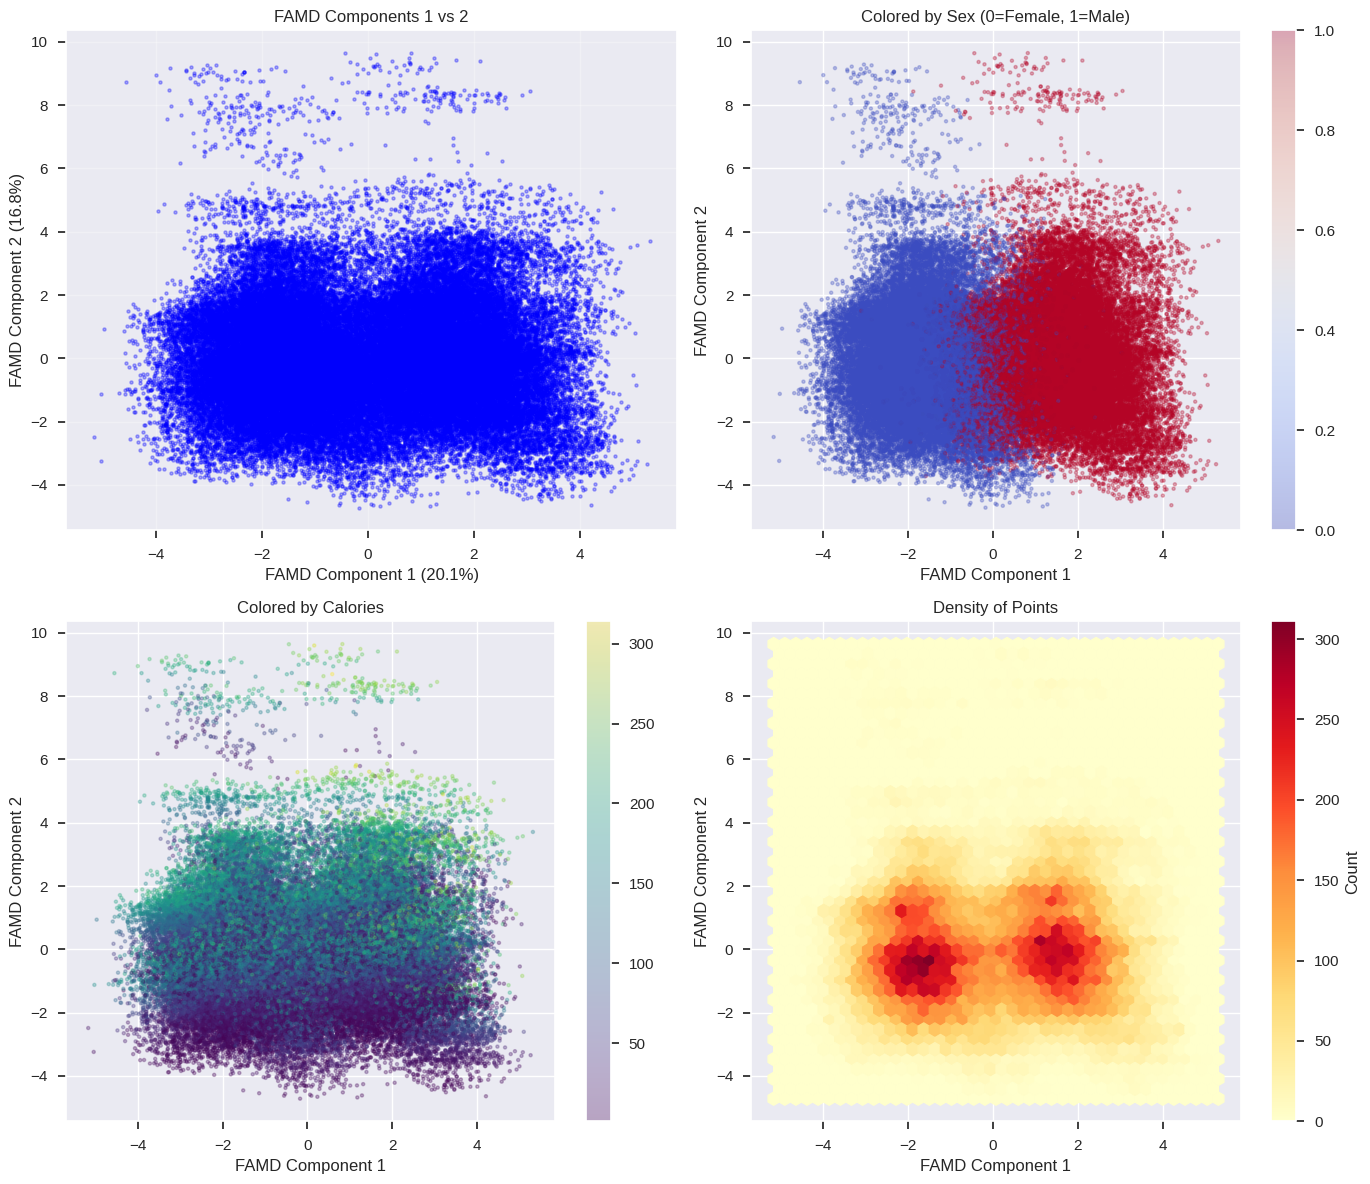

✅ FAMD components plot saved as '01_famd_components_plot.png'


In [ ]:
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Simple scatter plot of FAMD1 vs FAMD2
scatter1 = axes[0, 0].scatter(
    train_famd_optimal.iloc[:, 0],
    train_famd_optimal.iloc[:, 1],
    c='blue',
    alpha=0.3,
    s=5
)
axes[0, 0].set_xlabel(f'FAMD Component 1 ({explained_inertia_optimal[0]:.1f}%)')
axes[0, 0].set_ylabel(f'FAMD Component 2 ({explained_inertia_optimal[1]:.1f}%)')
axes[0, 0].set_title('FAMD Components 1 vs 2')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Colored by Sex
scatter2 = axes[0, 1].scatter(
    train_famd_optimal.iloc[:, 0],
    train_famd_optimal.iloc[:, 1],
    c=features_encoded['Sex'],
    cmap='coolwarm',
    alpha=0.3,
    s=5
)
axes[0, 1].set_xlabel('FAMD Component 1')
axes[0, 1].set_ylabel('FAMD Component 2')
axes[0, 1].set_title('Colored by Sex (0=Female, 1=Male)')
plt.colorbar(scatter2, ax=axes[0, 1])

# Plot 3: Colored by Calories
scatter3 = axes[1, 0].scatter(
    train_famd_optimal.iloc[:, 0],
    train_famd_optimal.iloc[:, 1],
    c=train_data['Calories'],
    cmap='viridis',
    alpha=0.3,
    s=5
)
axes[1, 0].set_xlabel('FAMD Component 1')
axes[1, 0].set_ylabel('FAMD Component 2')
axes[1, 0].set_title('Colored by Calories')
plt.colorbar(scatter3, ax=axes[1, 0])

# Plot 4: Density plot (hexbin)
hb = axes[1, 1].hexbin(
    train_famd_optimal.iloc[:, 0],
    train_famd_optimal.iloc[:, 1],
    gridsize=40,
    cmap='YlOrRd'
)
axes[1, 1].set_xlabel('FAMD Component 1')
axes[1, 1].set_ylabel('FAMD Component 2')
axes[1, 1].set_title('Density of Points')
plt.colorbar(hb, ax=axes[1, 1], label='Count')

plt.tight_layout()
plt.savefig('01_famd_components_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ FAMD components plot saved as '01_famd_components_plot.png'")

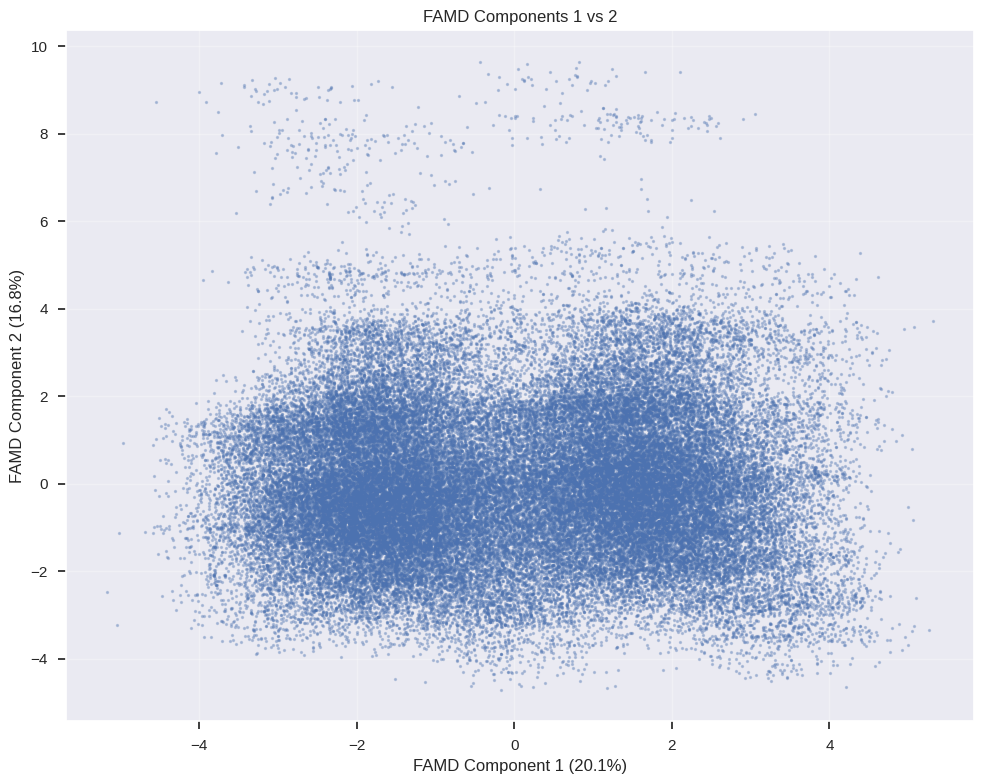

Explained variance: 20.1% + 16.8% = 36.9%


In [ ]:
# Plot
plt.figure(figsize=(10, 8))
plt.scatter(train_famd_optimal.iloc[:, 0], train_famd_optimal.iloc[:, 1], alpha=0.3, s=2)
plt.xlabel(f'FAMD Component 1 ({explained_inertia_optimal[0]:.1f}%)')
plt.ylabel(f'FAMD Component 2 ({explained_inertia_optimal[1]:.1f}%)')
plt.title('FAMD Components 1 vs 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('famd_components_minimal.png', dpi=300)
plt.show()

print(f"Explained variance: {explained_inertia_optimal[0]:.1f}% + {explained_inertia_optimal[1]:.1f}% = {sum(explained_inertia_optimal[:2]):.1f}%")

K prototype

In [ ]:
print("\nSTEP 2: Preparing data for K-Prototypes...")

# Select features for clustering
# Numerical features
numerical_cols = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
                  'Body_Temp']

# Categorical feature (Sex)
categorical_cols = ['Sex']

# Create feature matrix
X = train_data[numerical_cols + categorical_cols].copy()



STEP 2: Preparing data for K-Prototypes...


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical for visualization later
le = LabelEncoder()
X_encoded = X.copy()
X_encoded['Sex'] = le.fit_transform(X_encoded['Sex'])

# Standardize numerical features for fair comparison
scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print(f"Features shape: {X_scaled.shape}")
print(f"Numerical features: {numerical_cols}")
print(f"Categorical feature: {categorical_cols}")

# Convert to numpy array for k-prototypes
X_array = X_scaled.values

# Identify categorical feature indices (Sex is last column)
categorical_indices = [len(numerical_cols)]  # Index of Sex column

Features shape: (70000, 7)
Numerical features: ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']
Categorical feature: ['Sex']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import prince

!pip install kmodes
from kmodes.kprototypes import KPrototypes

In [ ]:
features = [
    'Age', 'Height', 'Weight',
    'Duration', 'Heart_Rate', 'Body_Temp',
     'Sex'
]

train_cluster = train_data[features].copy()

In [ ]:
categorical_cols = ['Sex']
categorical_indices = [train_cluster.columns.get_loc(col) for col in categorical_cols]

print("Categorical indices:", categorical_indices)

Categorical indices: [6]


In [ ]:
numeric_cols = train_cluster.columns.difference(categorical_cols)

scaler = StandardScaler()
train_cluster[numeric_cols] = scaler.fit_transform(train_cluster[numeric_cols])

In [ ]:
train_matrix = train_cluster.to_numpy()

In [ ]:
elbow_sample = train_cluster.sample(n=15000, random_state=42)
elbow_matrix = elbow_sample.to_numpy()

cost = []
K = range(2, 8)

for k in K:
    kproto = KPrototypes(
        n_clusters=k,
        init='Cao',
        n_init=1,
        max_iter=20,
        random_state=42
    )
    kproto.fit_predict(elbow_matrix, categorical=categorical_indices)
    cost.append(kproto.cost_)

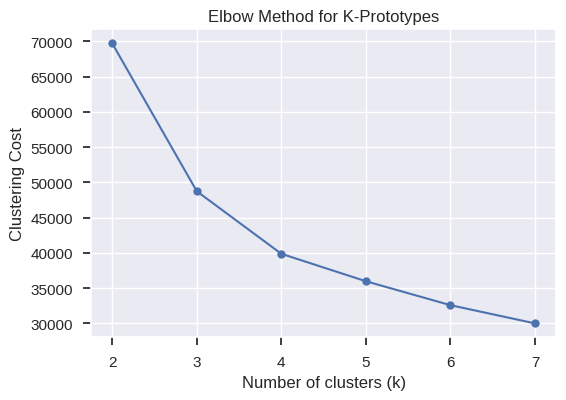

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(K, cost, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Clustering Cost')
plt.title('Elbow Method for K-Prototypes')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

!pip install gower
import gower
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score

In [ ]:
sil_sample = train_cluster.sample(n=5000, random_state=42)
sil_matrix = sil_sample.to_numpy()

In [ ]:
gower_dist = gower.gower_matrix(sil_sample)

In [ ]:
sil_scores = []
K = range(2, 8)

for k in K:
    kproto = KPrototypes(
        n_clusters=k,
        init='Cao',
        n_init=1,
        max_iter=20,
        random_state=42
    )

    labels = kproto.fit_predict(
        sil_matrix,
        categorical=categorical_indices
    )

    score = silhouette_score(
        gower_dist,
        labels,
        metric='precomputed'
    )

    sil_scores.append(score)

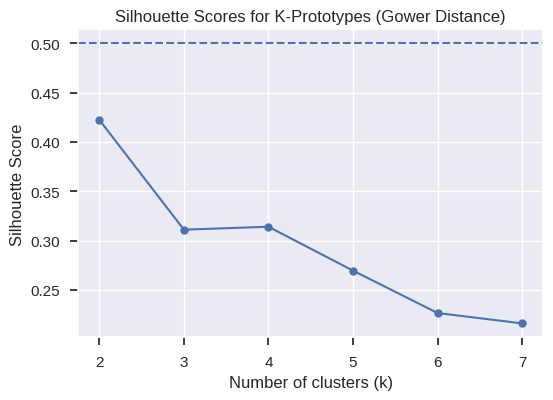

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Prototypes (Gower Distance)")
plt.axhline(0.5, linestyle='--')
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    'Age', 'Height', 'Weight',
    'Duration', 'Heart_Rate',
    'Body_Temp'
]

X_num = train_data[numeric_cols]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_components,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = train_data_with_clusters['Cluster'].values

In [ ]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.45361075 0.32650053]
Total explained variance: 0.7801112825354564


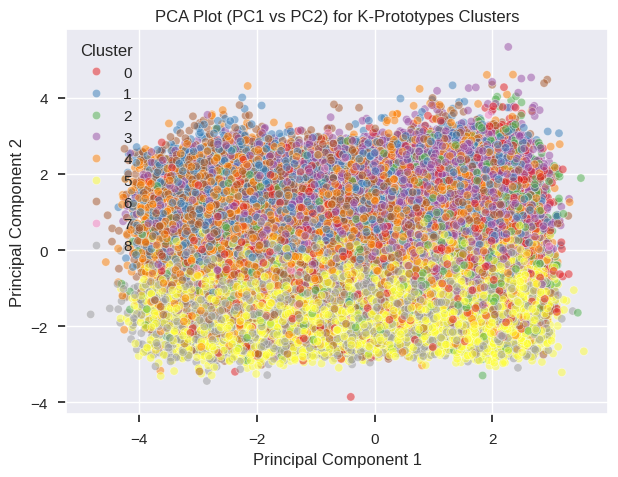

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    alpha=0.5
)

plt.title("PCA Plot (PC1 vs PC2) for K-Prototypes Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()